# combining results: binary location + added dispersion

In [1]:
# script_path = "/n/home02/amphillips/p26/scripts" # for cannon
import sys
script_path = '/Users/anyaphillips/Desktop/harvard/research/papers/p26/scripts'
sys.path.append('/Users/anyaphillips/Downloads/software/petar_install/include')

import petar
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from astropy.table import Table
from scipy.stats import binned_statistic_2d

import astropy.coordinates as coord
import astropy.units as u
import numpy as np
import gala.coordinates as gc
import gala.dynamics as gd
import gala.potential as gp
from gala.dynamics import mockstream as ms

from gala.units import galactic

from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib import gridspec
from matplotlib.lines import Line2D


from tqdm import tqdm

import pandas as pd

sys.path.append(script_path)
import PETAR_ANALYSIS_FUNCTIONS as paf
import astropy.constants as const
from streamframe import StreamFrame
from scipy.stats import binned_statistic
from matplotlib.gridspec import GridSpecFromSubplotSpec

import matplotlib.pyplot as plt
plt.style.use(script_path+'/vedant.mplstyle')
%config InlineBackend.figure_format='retina'

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.colors import LinearSegmentedColormap
from scipy.optimize import curve_fit
from scipy.stats import binom


import io
from matplotlib.transforms import Bbox


Duplicate key in file PosixPath('/Users/anyaphillips/.matplotlib/stylelib/vedant.mplstyle'), line 46 ('lines.linewidth : 3')

Bad key hist.type in file /Users/anyaphillips/.matplotlib/stylelib/vedant.mplstyle, line 45 ('hist.type : step')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.0/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution
/opt/anaconda3/envs/petar_env3/lib/python3.10/site-packages/matplotlib_inline/config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


In [5]:
# paths = paf.define_paths()
lm_colors, hm_colors, simcolors = paf.define_simcolors()
time_cmap = paf.define_time_cmap()

init_displacements = paf.define_init_displacements()
apocenters = paf.define_apocenters()

tperi_8 = 10499 # 
tperi_14 = 6549 # present in transfir_dir14 on my machine
tperis = [tperi_8, tperi_14]

ph = "/Users/anyaphillips/Desktop/harvard/research/data/grid_summary/"#
paths = [ph+"transfer_dir8/", ph+"transfer_dir14/"]


In [45]:
colors_list = ['#E3F4C8','#B6D6CC',
               '#74A4BC', '#29339B']
labels_list = ["all particle data", "detected binaries with 2 RVs", 
               "detected binaries with 3 RVs", "intrinsic dispersion"]

In [60]:
def concatenate_stream_data(coords, single_coords, binary_coords, binaries,
                             all_particles, 
                             detected=None, do_detection=True,
                               singles=None):
    """
    for an "all particles" population, a single population, and a binary population
    where some subset of the binaries are undetected, make stream coordinate arrays
    of the single + detected binary CoM + undetected binary _primary_ populations.

    if return_masses==True, pass singles as well.
    """
    ## create stream coordinate arrays for the CoMs of the detected binaries
    if detected is None:
        detected = np.array([True]*len(binaries.mass))
    
    
    b_phi1 = binary_coords['phi1'][detected]
    b_phi2 = binary_coords['phi2'][detected]
    b_r = binary_coords['r'][detected]
    b_vr = binary_coords['vr'][detected]

    ### creat stream coord arrays for the singles
    s_phi1 = single_coords['phi1']
    s_phi2 = single_coords['phi2']
    s_r = single_coords['r']
    s_vr = single_coords['vr']



    if do_detection==True:
        ## handle the "undetected" systems.
        undetected = ~detected

        # masses and IDs of all binary components
        m1, m2 = binaries.p1.mass, binaries.p2.mass
        id1, id2 = binaries.p1.id, binaries.p2.id

        # determine which IDs correspond to the primary (more massive)
        primary_ids = np.where(m1>=m2, id1, id2)

        # get IDs of all stars in undetected binaries
        undetected_p1_ids = binaries.p1.id[undetected]
        undetected_p2_ids = binaries.p2.id[undetected]
        all_undetected_ids = np.concatenate([undetected_p1_ids, undetected_p2_ids])

        # determine which _primaries_ are in undetected binaries
        undetected_primary_flag = np.isin(primary_ids, all_undetected_ids)
        undetected_primary_ids = primary_ids[undetected_primary_flag]

        ### find the indices of stream coords containing the primaries in undetected binaries
        undetected_primary_indices = np.nonzero(np.isin(all_particles.id, undetected_primary_ids))[0]

        ### create coordinate arrays containing the stream coordinates of the undetected primaries
        p1_phi1 = coords["phi1"][undetected_primary_indices]
        p1_phi2 = coords['phi2'][undetected_primary_indices]
        p1_r = coords['r'][undetected_primary_indices]
        p1_vr = coords['vr'][undetected_primary_indices]
        

        # concatenate all stream coordinate data:
        all_phi1 = np.concatenate([s_phi1, b_phi1, p1_phi1])
        all_phi2 = np.concatenate([s_phi2, b_phi2, p1_phi2])
        all_r = np.concatenate([s_r, b_r, p1_r])
        all_vr = np.concatenate([s_vr, b_vr, p1_vr])


    if do_detection==False:
        all_phi1 = np.concatenate([s_phi1, b_phi1])
        all_phi2 = np.concatenate([s_phi2, b_phi2])
        all_r = np.concatenate([s_r, b_r])
        all_vr = np.concatenate([s_vr, b_vr])


    return all_phi1, all_phi2, all_r, all_vr
   

In [82]:
def dispersion_5_95(data):
    l, h = np.percentile(data, [5,95])
    # print(l, h)
    return h-l

# dispersion_5_95(np.arange(0, 11, 1))

75


100%|██████████| 1549/1549 [00:00<00:00, 21927.47it/s]


successfully concatenated streamframe data
successfully concatenated streamframe data
60


100%|██████████| 2123/2123 [00:00<00:00, 21873.51it/s]


successfully concatenated streamframe data
successfully concatenated streamframe data


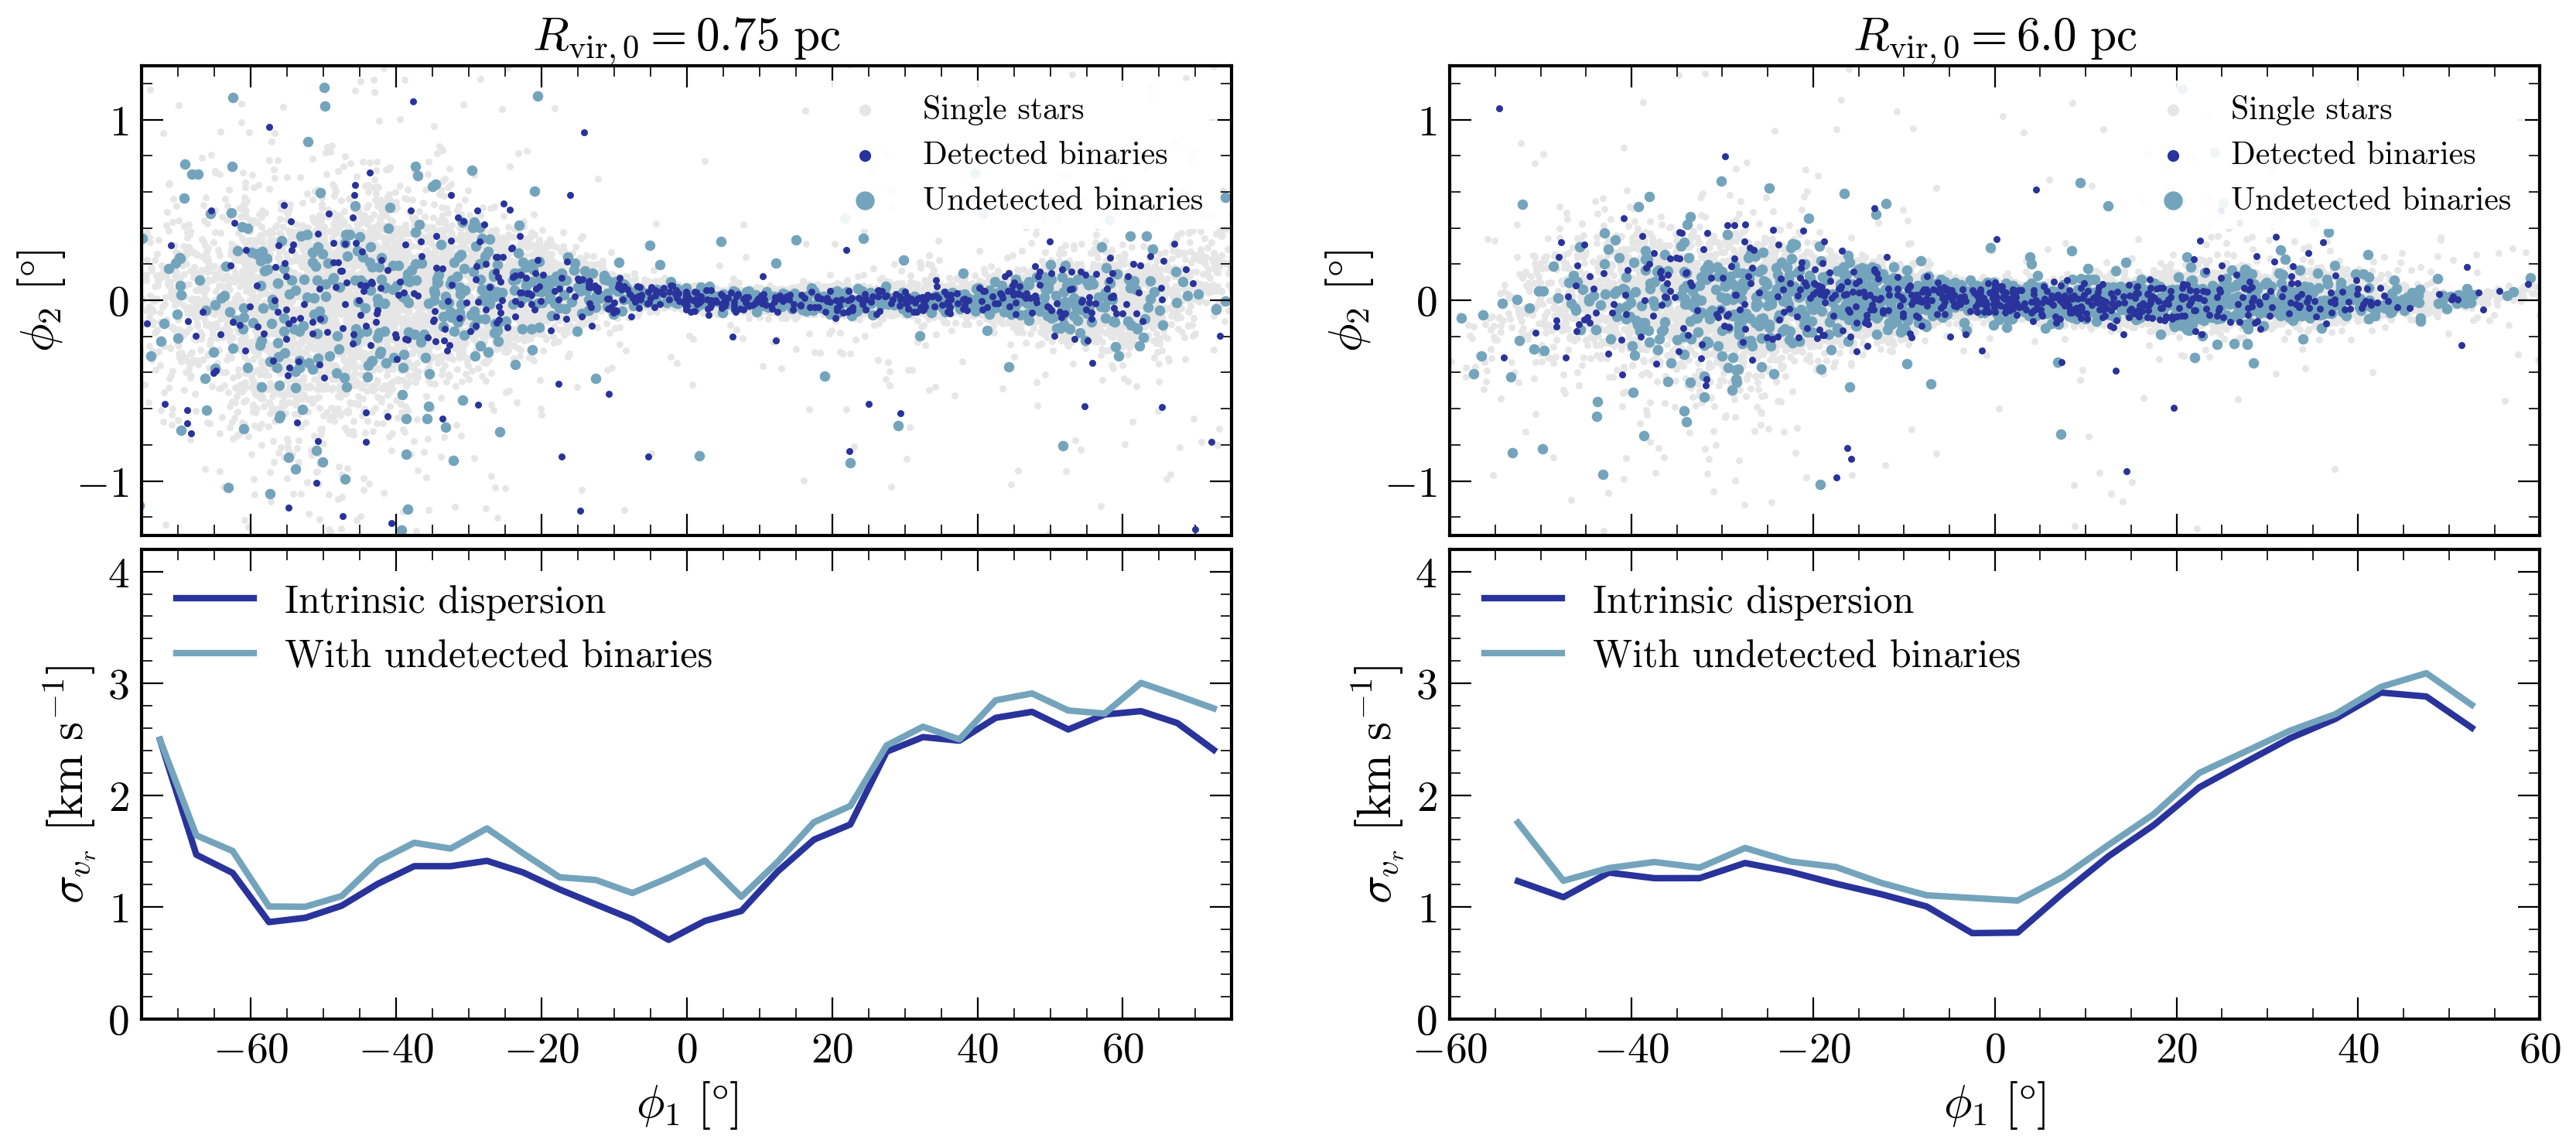

In [116]:
sim_n = [8,14]
undetected_color=colors_list[-2]
detected_color=colors_list[-1]

titles = [r'$R_{\rm vir,0}=0.75~\rm pc$', r'$R_{\rm vir,0}=6.0~\rm pc$']

phimax_vals=[75, 60]


fig, axs_grid = plt.subplots(2,2,figsize=[20, 8], sharex=False)
plt.subplots_adjust(hspace=0.03)

for k, n in enumerate(sim_n):
    phimax=phimax_vals[k]
    print(phimax)
    axs = axs_grid[:,k]
    rng = np.random.default_rng(seed=42)

    i = tperis[k]
    path = paths[k]

    particle_data, streamframe_data = paf.load_coords_v2(
        path, i, tdis_estimate=i-1, use_prog=False
    )
    all_particles, singles, binaries = particle_data
    coords, single_coords, binary_coords = streamframe_data



    # which binaries are detected:
    params, _ = paf.get_orbital_params(paths=[path],
                                       times = [i],
                                       n=0, # since i am giving length 1 arrays.
                                       rng=rng)
    obstimes = paf.get_obstimes(N_obsm=3, N=len(params), rng=rng)
    rvs = paf.get_rvs(params, obstimes)
    detected, dvs = paf.get_detections(
        e_rv=0.1,
        rvs_all = rvs[:,:-1],
        v0_vals = params[:,0]*u.km/u.s,
        bool_arr='detet'
    )

    detection_arrays = [np.array([True]*len(detected)), detected]

    phi1, phi2, r, vr, in_MW, final_clip = paf.trim_stream_data(
        binary_coords['phi1'],binary_coords['phi2'], binary_coords['r'], binary_coords['vr'], apocenters[n]
    )

    _,_, poly, fit = paf.straighten_stream_polynomial(phi1,
                                                  phi2,
                                                  return_poly_fn=True,
                                                  degree=5)


    phi2_straight = binary_coords['phi2'] - poly(binary_coords['phi1'], *fit)


### straighten/trim single stars as well..
    phi1_s, phi2_s, r_s, vr_s, in_MW_s, final_clip_s = paf.trim_stream_data(
        single_coords['phi1'],single_coords['phi2'], single_coords['r'], single_coords['vr'], apocenters[n]
    )
    phi2_straight_s = phi2_s - poly(phi1_s, *fit)

    ### NOW DO THE dispersions in phi1 bins

    bins = np.arange(-phimax, phimax+5, 5)
    bin_centers = (bins[1:]+bins[:-1])/2
    
    hist_yvals = []
    selections = []
    for d in detection_arrays:
        # 1. concatenate single/binary info -- this includes detections, so that undetected binaries count the individual RVs of their primaries...
        all_phi1, all_phi2, all_r, all_vr = paf.concatenate_stream_data(coords, single_coords, binary_coords, 
                                                                    binaries, all_particles, detected=d)
        print("successfully concatenated streamframe data")
        
        # 2. trim the concatenated data
        phi1_all_trimmed, phi2_all_trimmed, r_all_trimmed, vr_all_trimmed, in_MW_all, final_clip_all = paf.trim_stream_data(
            all_phi1, all_phi2, all_r, all_vr, apocenters[n]
        )

        # 3. fit a polynomial to the _TRIMMED_ data
        _, vr_straight, poly, fit = paf.straighten_stream_polynomial(phi1_all_trimmed, vr_all_trimmed, return_poly_fn=True)
        
        # 4. subtract the polynomial from the un-trimmed data
        # vr_straight = all_vr - poly(all_phi1, *fit)

        #### bin vr along phi1. I can do the selection based on stream trimming here since we've already 
        # included the detected/not detected business

        sigv_binned, _, _ = binned_statistic(x=phi1_all_trimmed, 
                                            values=vr_straight, 
                                            statistic=dispersion_5_95,
                                            bins=bins)
        counts, _, _ = binned_statistic(x=phi1_all_trimmed, values=vr_straight, statistic='count', bins=bins)
        sel = counts>=50
        hist_yvals.append(sigv_binned)
        selections.append(sel)



    # fig, axs = plt.subplots(2,1, figsize=[10,8], sharex=True)
    # plt.subplots_adjust(wspace=0.03, hspace=0.03)

    axs[0].scatter(phi1_s, phi2_straight_s, c='0.9', s=5, label='Single stars', zorder=1, rasterized=True)
    axs[0].scatter(binary_coords['phi1'][detected], 
               phi2_straight[detected], 
               s=5, c=detected_color,#simcolors[n],
                 rasterized=True, zorder=2,
                 label='Detected binaries')
    axs[0].scatter(binary_coords['phi1'][~detected], 
               phi2_straight[~detected], 
               marker="o", c=undetected_color, s=15,
               rasterized=True, zorder=1,
               label='Undetected binaries')
    
    axs[0].legend(loc='upper right', framealpha=0.9, fontsize=15, markerscale=2)
    axs[0].set_ylabel(r'$\phi_2\ [\degree]$')

    axs[0].set_ylim(-1.3,1.3)
    axs[0].set_xlim(-phimax,phimax)
    axs[1].set_xlim(-phimax, phimax)

    axs[0].set_xticklabels([])


    axs[1].plot(bin_centers[selections[0]], 
                hist_yvals[0][selections[0]], c=detected_color, label='Intrinsic dispersion')
    axs[1].plot(bin_centers[selections[1]], 
                hist_yvals[1][selections[1]], c=undetected_color, label='With undetected binaries')
    axs[1].set_ylabel(r'$\sigma_{v_r}\ [\rm km~s^{-1}]$')

    axs[1].legend(loc='upper left')
    axs[1].set_xlabel(r'$\phi_1\ [\degree]$')

    axs[0].set_title(titles[k])

    axs[1].set_ylim(0, 4.2)

plt.savefig('plots/dispersion_along_stream_from_binaries.pdf', dpi=300, bbox_inches='tight')